# Seleccion de Caracteristicas Multimetodo (Optimizado)
Objetivo: seleccionar variables para `tipo_violencia` y `nivel_riesgo_victima` con una estrategia multimetodo, controlando el consumo de RAM y exportando resultados en CSV.

## 1) Librerias

In [1]:
# !pip install pandas pyarrow numpy scipy scikit-learn matplotlib seaborn
import gc
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 180)
sns.set(style="whitegrid")


## 2) Carga de datos

In [2]:
PARQUET_PATH = "/home/munasqa/MAESTRIA/opencode/base_modelado.parquet"
df = pd.read_parquet(PARQUET_PATH)

if "nivel_de_riesgo_victima" in df.columns and "nivel_riesgo_victima" not in df.columns:
    df = df.rename(columns={"nivel_de_riesgo_victima": "nivel_riesgo_victima"})

targets = ["tipo_violencia", "nivel_riesgo_victima"]
for t in targets:
    if t not in df.columns:
        raise ValueError(f"Falta target: {t}")

print("Shape base:", df.shape)
display(df[targets].head())


Shape base: (932860, 131)


,tipo_violencia,nivel_riesgo_victima
0,1,1
1,0,0
2,0,0
3,2,1
4,2,1


## 3) Preparacion de features (ahorro de RAM)
- Se excluyen targets y columnas de leakage obvio.
- Se tipifican categoricas y numericas.
- Se aplica downcast numerico (`float32`/`int32`) para reducir memoria.

In [3]:
leakage_obvio = [
    "tipo_violencia",
    "nivel_riesgo_victima",
    "tipo_violencia_lbl",
    "nivel_riesgo_victima_lbl",
    "tipo_violencia_orig",
    "nivel_riesgo_victima_orig",
]
features = [c for c in df.columns if c not in leakage_obvio]
X_raw = df[features].copy()

for c in X_raw.columns:
    if str(X_raw[c].dtype) in ["object", "category"]:
        X_raw[c] = X_raw[c].astype(str).fillna("desconocido")
    else:
        X_raw[c] = pd.to_numeric(X_raw[c], errors="coerce")
        med = X_raw[c].median()
        X_raw[c] = X_raw[c].fillna(med if pd.notna(med) else 0)
        X_raw[c] = pd.to_numeric(X_raw[c], downcast="float")

print("Features candidatas:", len(features))
print("Memoria aprox X_raw (MB):", round(X_raw.memory_usage(deep=True).sum() / 1024**2, 2))


Features candidatas: 127
Memoria aprox X_raw (MB): 6024.19


## 3.1) Chequeo rapido de leakage (antes de seleccionar variables)
Se busca detectar columnas sospechosas: copias del target, derivados directos (`*_orig`, `*_lbl`) o variables con acuerdo casi perfecto con el target.

In [4]:
def leakage_audit(X_df, y_series, target_name, sample_size=120000, random_state=42):
    y = pd.to_numeric(y_series, errors="coerce")
    mask = y.notna()
    y = y[mask].astype(int)
    X = X_df.loc[mask].copy()

    if len(y) > sample_size:
        _, X, _, y = train_test_split(X, y, test_size=sample_size, stratify=y, random_state=random_state)

    suspicious_name_tokens = ["_orig", "_lbl", "tipo_violencia", "nivel_riesgo"]
    by_name = [c for c in X.columns if any(tok in c for tok in suspicious_name_tokens)]

    rows = []
    y_str = y.astype(str)
    for c in X.columns:
        x = X[c]
        x_num = pd.to_numeric(x, errors="coerce")

        exact_num = False
        if x_num.notna().sum() > 0:
            valid = x_num.notna()
            exact_num = bool((x_num[valid].astype(int) == y[valid]).all()) if valid.sum() > 0 else False

        x_str = x.astype(str)
        agreement = float((x_str == y_str).mean())

        rows.append((c, exact_num, agreement))

    rep = pd.DataFrame(rows, columns=["feature", "exact_copy_numeric", "agreement_vs_target_str"])
    rep["name_suspicious"] = rep["feature"].isin(by_name).astype(int)
    rep["leakage_flag"] = ((rep["exact_copy_numeric"]) | (rep["agreement_vs_target_str"] >= 0.98) | (rep["name_suspicious"] == 1)).astype(int)

    rep = rep.sort_values(["leakage_flag", "agreement_vs_target_str"], ascending=[False, False]).reset_index(drop=True)
    return rep

# Ejecutar auditoria de leakage para ambos targets
leak_tipo = leakage_audit(X_raw, df["tipo_violencia"], "tipo_violencia")
leak_riesgo = leakage_audit(X_raw, df["nivel_riesgo_victima"], "nivel_riesgo_victima")

print("Posibles leakage - tipo_violencia")
display(leak_tipo.head(20))
print("Posibles leakage - nivel_riesgo_victima")
display(leak_riesgo.head(20))

# Si detectas columnas no validas para modelado, agrégalas a leakage_obvio en la celda 3.


Posibles leakage - tipo_violencia


,feature,exact_copy_numeric,agreement_vs_target_str,name_suspicious,leakage_flag
0,primera_vez_agrede,False,0.446492,0,0
1,victima_extranjera,False,0.446325,0,0
2,continua_recibiendo_tratamiento,False,0.446167,0,0
3,agresor_extranjero,False,0.444917,0,0
4,caso_tentativa_de_feminicidio,False,0.425850,0,0
5,informante,False,0.425642,0,0
6,trabaja_victima,False,0.425167,0,0
7,interpuso_denuncia,False,0.424358,0,0
8,sexo_victima,False,0.421283,0,0
9,estudia,False,0.406950,0,0


Posibles leakage - nivel_riesgo_victima


,feature,exact_copy_numeric,agreement_vs_target_str,name_suspicious,leakage_flag
0,desea_patrocinio_legal,False,0.515200,0,0
1,estado_victima_u_a,False,0.514025,0,0
2,victima_peruana,False,0.512600,0,0
3,victima_cuenta_dni,False,0.510125,0,0
4,agresor_peruano,False,0.508542,0,0
5,agresor_cuenta_dni,False,0.504792,0,0
6,redes_fam_soc,False,0.495275,0,0
7,ningun_tratamiento,False,0.490700,0,0
8,sexo_agresor,False,0.490358,0,0
9,vinculo_afectivo_familia,False,0.484008,0,0


## 4) Que hace cada algoritmo (explicado simple)

- **Cramer's V (filtro)**: mide asociacion entre una feature categorica y el target. Cerca de 0 = poca asociacion; cerca de 1 = alta asociacion.
- **Mutual Information (filtro)**: mide cuanta informacion aporta una variable sobre el target, capturando relaciones no lineales. Mayor MI = mayor utilidad potencial.
- **Random Forest Importance (embedded)**: el bosque asigna importancia segun cuanto ayuda una variable a reducir impureza al hacer splits.
- **Permutation Importance (embedded/model-agnostic)**: con el modelo ya entrenado, se desordena una variable y se mide cuanto cae el desempeño. Si cae mucho, la variable era importante.
- **RFECV (wrapper)**: elimina variables en pasos, reentrena y valida con CV para encontrar el subconjunto que mejor rendimiento logra.

Finalmente, se normalizan rankings y se crea un **score de consenso** ponderado para tener un ranking robusto.

## 5) Funciones auxiliares

In [5]:
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan, np.nan
    chi2, p, _, _ = chi2_contingency(tab)
    n = tab.values.sum()
    r, k = tab.shape
    den = min(r - 1, k - 1)
    v = np.sqrt((chi2 / n) / den) if den > 0 else np.nan
    return v, p


def cap_cardinality(series, top_n=80):
    s = series.astype(str)
    keep = s.value_counts(dropna=False).head(top_n).index
    return s.where(s.isin(keep), "otros")


def to_ordinal_encoded(X_df):
    X = X_df.copy()
    cat_cols = [c for c in X.columns if str(X[c].dtype) in ["object", "category"]]
    num_cols = [c for c in X.columns if c not in cat_cols]

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    if cat_cols:
        X[cat_cols] = enc.fit_transform(X[cat_cols]).astype(np.float32)

    for c in num_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce").fillna(pd.to_numeric(X[c], errors="coerce").median())
        X[c] = pd.to_numeric(X[c], downcast="float")

    return X


def rank_to_score(df_rank, score_col, feature_col="feature", descending=True):
    r = df_rank[[feature_col, score_col]].dropna().copy()
    if r.empty:
        return pd.DataFrame(columns=["feature", "score"])
    r = r.sort_values(score_col, ascending=not descending).reset_index(drop=True)
    r["score"] = np.linspace(1.0, 0.0, len(r), endpoint=False)
    return r[[feature_col, "score"]]


def run_feature_selection_for_target(df_all, X_all, target, sample_size=50000, random_state=42):
    y_full = pd.to_numeric(df_all[target], errors="coerce")
    mask = y_full.notna()
    y_full = y_full[mask].astype(int)
    X_full = X_all.loc[mask]

    if len(y_full) > sample_size:
        _, X_use, _, y = train_test_split(
            X_full,
            y_full,
            test_size=sample_size,
            stratify=y_full,
            random_state=random_state,
        )
    else:
        X_use = X_full.copy()
        y = y_full.copy()

    print(f"Target: {target} | muestra usada: {len(y)}")

    rows_cv = []
    y_cat = y.astype(str)
    for c in X_use.columns:
        vals = cap_cardinality(X_use[c], top_n=80)
        v, p = cramers_v(vals, y_cat)
        rows_cv.append((c, v, p))
    r_cv = pd.DataFrame(rows_cv, columns=["feature", "cramers_v", "p_value"]).dropna()

    X_enc = to_ordinal_encoded(X_use)
    mi_vals = mutual_info_classif(X_enc, y, discrete_features="auto", random_state=random_state)
    r_mi = pd.DataFrame({"feature": X_enc.columns, "mi": mi_vals})

    Xtr, Xte, ytr, yte = train_test_split(X_enc, y, test_size=0.2, stratify=y, random_state=random_state)

    rf = RandomForestClassifier(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=5,
        random_state=random_state,
        n_jobs=2,
        class_weight="balanced_subsample",
    )
    rf.fit(Xtr, ytr)
    r_rf = pd.DataFrame({"feature": X_enc.columns, "rf_importance": rf.feature_importances_})

    top_perm = r_rf.sort_values("rf_importance", ascending=False).head(min(40, len(r_rf)))["feature"].tolist()
    rf_perm = RandomForestClassifier(
        n_estimators=80,
        max_depth=16,
        min_samples_leaf=5,
        random_state=random_state,
        n_jobs=2,
        class_weight="balanced_subsample",
    )
    rf_perm.fit(Xtr[top_perm], ytr)
    perm = permutation_importance(
        rf_perm,
        Xte[top_perm],
        yte,
        n_repeats=3,
        random_state=random_state,
        n_jobs=2,
        scoring="f1_macro",
    )
    r_perm = pd.DataFrame({"feature": top_perm, "perm_importance": perm.importances_mean})

    top_for_rfe = r_mi.sort_values("mi", ascending=False).head(min(25, len(r_mi)))["feature"].tolist()
    X_rfe = X_enc[top_for_rfe].copy()
    rfe_est = RandomForestClassifier(
        n_estimators=80,
        max_depth=14,
        min_samples_leaf=6,
        random_state=random_state,
        n_jobs=2,
        class_weight="balanced_subsample",
    )
    rfecv = RFECV(
        estimator=rfe_est,
        step=5,
        cv=3,
        scoring="f1_macro",
        min_features_to_select=5,
        n_jobs=2,
    )
    rfecv.fit(X_rfe, y)
    r_rfe = pd.DataFrame({"feature": X_rfe.columns, "rfe_rank": rfecv.ranking_, "rfe_selected": rfecv.support_.astype(int)})

    s_cv = rank_to_score(r_cv, "cramers_v", descending=True)
    s_mi = rank_to_score(r_mi, "mi", descending=True)
    s_rf = rank_to_score(r_rf, "rf_importance", descending=True)
    s_perm = rank_to_score(r_perm, "perm_importance", descending=True)
    s_rfe = r_rfe[["feature", "rfe_selected"]].copy()
    s_rfe["score"] = s_rfe["rfe_selected"].astype(float)
    s_rfe = s_rfe[["feature", "score"]]

    pool = pd.DataFrame({"feature": X_enc.columns}).drop_duplicates()
    for name, s in [("cv", s_cv), ("mi", s_mi), ("rf", s_rf), ("perm", s_perm), ("rfe", s_rfe)]:
        pool = pool.merge(s.rename(columns={"score": f"score_{name}"}), on="feature", how="left")

    pool = pool.fillna(0)
    pool["score_consenso"] = (
        0.20 * pool["score_cv"]
        + 0.25 * pool["score_mi"]
        + 0.25 * pool["score_rf"]
        + 0.20 * pool["score_perm"]
        + 0.10 * pool["score_rfe"]
    )
    pool = pool.sort_values("score_consenso", ascending=False).reset_index(drop=True)

    yhat = rf.predict(Xte)
    f1m = f1_score(yte, yhat, average="macro")

    out = {
        "cv": r_cv.sort_values("cramers_v", ascending=False),
        "mi": r_mi.sort_values("mi", ascending=False),
        "rf": r_rf.sort_values("rf_importance", ascending=False),
        "perm": r_perm.sort_values("perm_importance", ascending=False),
        "rfe": r_rfe.sort_values(["rfe_selected", "rfe_rank"], ascending=[False, True]),
        "consenso": pool,
        "rf_f1_macro_test": f1m,
    }

    del X_full, X_use, X_enc, Xtr, Xte, ytr, yte, rf, rf_perm, X_rfe
    gc.collect()

    return out


def pareto_front(df_obj):
    keep = np.ones(len(df_obj), dtype=bool)
    vals = df_obj[["obj_error", "obj_nfeat"]].to_numpy()
    for i in range(len(vals)):
        if not keep[i]:
            continue
        dominated = (vals[:, 0] <= vals[i, 0]) & (vals[:, 1] <= vals[i, 1]) & ((vals[:, 0] < vals[i, 0]) | (vals[:, 1] < vals[i, 1]))
        dominated[i] = False
        if dominated.any():
            keep[i] = False
    return df_obj.loc[keep].copy()


def run_moes_rf_for_target(df_all, X_all, target, sample_size=50000, random_state=42, n_generations=10, pop_size=40, min_features=8):
    y_full = pd.to_numeric(df_all[target], errors="coerce")
    mask = y_full.notna()
    y_full = y_full[mask].astype(int)
    X_full = X_all.loc[mask]

    if len(y_full) > sample_size:
        _, X_use, _, y = train_test_split(X_full, y_full, test_size=sample_size, stratify=y_full, random_state=random_state)
    else:
        X_use = X_full.copy()
        y = y_full.copy()

    X_enc = to_ordinal_encoded(X_use)
    Xtr, Xte, ytr, yte = train_test_split(X_enc, y, test_size=0.2, stratify=y, random_state=random_state)

    seed_rf = RandomForestClassifier(n_estimators=80, max_depth=14, min_samples_leaf=6, random_state=random_state, n_jobs=2, class_weight="balanced_subsample")
    seed_rf.fit(Xtr, ytr)
    r_seed = pd.DataFrame({"feature": X_enc.columns, "imp": seed_rf.feature_importances_}).sort_values("imp", ascending=False)
    candidate_features = r_seed.head(min(40, len(r_seed)))["feature"].tolist()

    rng = np.random.default_rng(random_state)

    def evaluate_subset(mask_arr):
        if mask_arr.sum() < min_features:
            return 1.0, 999
        sel = [candidate_features[i] for i in range(len(candidate_features)) if mask_arr[i] == 1]
        model = RandomForestClassifier(n_estimators=70, max_depth=12, min_samples_leaf=6, random_state=random_state, n_jobs=2, class_weight="balanced_subsample")
        model.fit(Xtr[sel], ytr)
        pred = model.predict(Xte[sel])
        f1m = f1_score(yte, pred, average="macro")
        return 1.0 - f1m, len(sel)

    pop = rng.integers(0, 2, size=(pop_size, len(candidate_features)), dtype=np.int8)
    for i in range(pop_size):
        if pop[i].sum() < min_features:
            idx = rng.choice(len(candidate_features), size=min_features, replace=False)
            pop[i, idx] = 1

    history = []
    for gen in range(n_generations):
        rows = []
        for i in range(pop.shape[0]):
            err, nfeat = evaluate_subset(pop[i])
            rows.append((gen, i, err, nfeat, pop[i].copy()))
        df_gen = pd.DataFrame(rows, columns=["gen", "idx", "obj_error", "obj_nfeat", "mask"])
        history.append(df_gen)

        front = pareto_front(df_gen[["obj_error", "obj_nfeat", "mask"]])
        elite_masks = front["mask"].tolist()

        new_pop = []
        while len(new_pop) < pop_size:
            p1 = elite_masks[rng.integers(0, len(elite_masks))]
            p2 = elite_masks[rng.integers(0, len(elite_masks))]
            cut = rng.integers(1, len(candidate_features) - 1)
            child = np.concatenate([p1[:cut], p2[cut:]]).astype(np.int8)
            mut = rng.random(len(candidate_features)) < 0.06
            child[mut] = 1 - child[mut]
            if child.sum() < min_features:
                idx = rng.choice(len(candidate_features), size=min_features, replace=False)
                child[idx] = 1
            new_pop.append(child)
        pop = np.array(new_pop, dtype=np.int8)

    all_runs = pd.concat(history, ignore_index=True)
    front_all = pareto_front(all_runs[["obj_error", "obj_nfeat", "mask"]])
    best = front_all.sort_values(["obj_error", "obj_nfeat"], ascending=[True, True]).iloc[0]
    best_mask = best["mask"]
    best_features = [candidate_features[i] for i in range(len(candidate_features)) if best_mask[i] == 1]

    out = pd.DataFrame({"feature": best_features})
    out["moes_rank"] = np.arange(1, len(out) + 1)

    return {
        "moes_selected": out,
        "moes_pareto": front_all.sort_values(["obj_error", "obj_nfeat"], ascending=[True, True]).reset_index(drop=True),
        "moes_error_best": float(best["obj_error"]),
        "moes_f1_best": float(1.0 - best["obj_error"]),
        "moes_n_features_best": int(best["obj_nfeat"]),
    }


## 6) Seleccion para `tipo_violencia`
Esta celda calcula ranking multimetodo, imprime tabla Markdown Top 30 y grafica ranking final de consenso.

Target: tipo_violencia | muestra usada: 500000
## Top 30 consenso para tipo_violencia
| feature                         |   score_consenso |   score_cv |   score_mi |   score_rf |   score_perm |   score_rfe |
|:--------------------------------|-----------------:|-----------:|-----------:|-----------:|-------------:|------------:|
| violacion                       |         0.98622  |   1        |   0.968504 |   0.976378 |        1     |           1 |
| empujones                       |         0.985945 |   0.984252 |   0.976378 |   1        |        0.975 |           1 |
| gritos_insultos                 |         0.974488 |   0.992126 |   0.992126 |   0.992126 |        0.9   |           1 |
| punetazos                       |         0.971496 |   0.976378 |   0.96063  |   0.984252 |        0.95  |           1 |
| bofetadas                       |         0.927874 |   0.937008 |   0.944882 |   0.937008 |        0.85  |           1 |
| otra_vpsi                       |         0.923976 

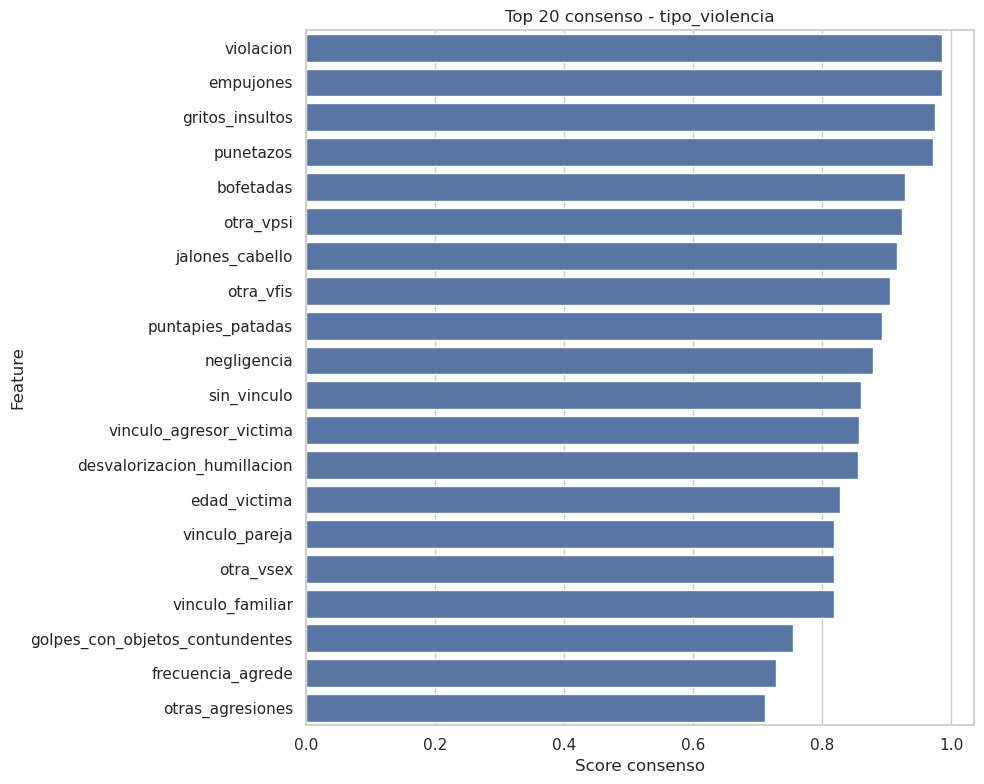

In [6]:
results = {}
SAMPLE_SIZE = 500000


results["tipo_violencia"] = run_feature_selection_for_target(
    df_all=df,
    X_all=X_raw,
    target="tipo_violencia",
    sample_size=SAMPLE_SIZE,
    random_state=52,
)

top30_tv = results["tipo_violencia"]["consenso"].head(30).copy()
print("## Top 30 consenso para tipo_violencia")
print(top30_tv[["feature", "score_consenso", "score_cv", "score_mi", "score_rf", "score_perm", "score_rfe"]].to_markdown(index=False))
print(f"\nF1 macro RF baseline (muestra): {results['tipo_violencia']['rf_f1_macro_test']:.4f}")

plt.figure(figsize=(10, 8))
sns.barplot(data=top30_tv.head(20), x="score_consenso", y="feature", orient="h")
plt.title("Top 20 consenso - tipo_violencia")
plt.xlabel("Score consenso")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 7) Seleccion para `nivel_riesgo_victima`
Mismo flujo: calculo multimetodo, tabla Markdown Top 30 y grafico de ranking final.

Target: nivel_riesgo_victima | muestra usada: 500000


/usr/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## Top 30 consenso para nivel_riesgo_victima
| feature                         |   score_consenso |   score_cv |   score_mi |   score_rf |   score_perm |   score_rfe |
|:--------------------------------|-----------------:|-----------:|-----------:|-----------:|-------------:|------------:|
| ubigeo_nombre                   |         0.993307 |   0.976378 |   0.992126 |   1        |        1     |           1 |
| cem                             |         0.981063 |   1        |   1        |   0.984252 |        0.925 |           1 |
| ubigeo_codigo                   |         0.963858 |   0.968504 |   0.984252 |   0.976378 |        0.9   |           1 |
| factor_agresor_consumo_alcohol  |         0.962835 |   0.992126 |   0.905512 |   0.992126 |        0.95  |           1 |
| amenaza_de_muerte               |         0.916732 |   0.984252 |   0.811024 |   0.968504 |        0.875 |           1 |
| factor_agresor_consume_droga    |         0.910472 |   0.96063  |   0.976378 |   0.937008 | 

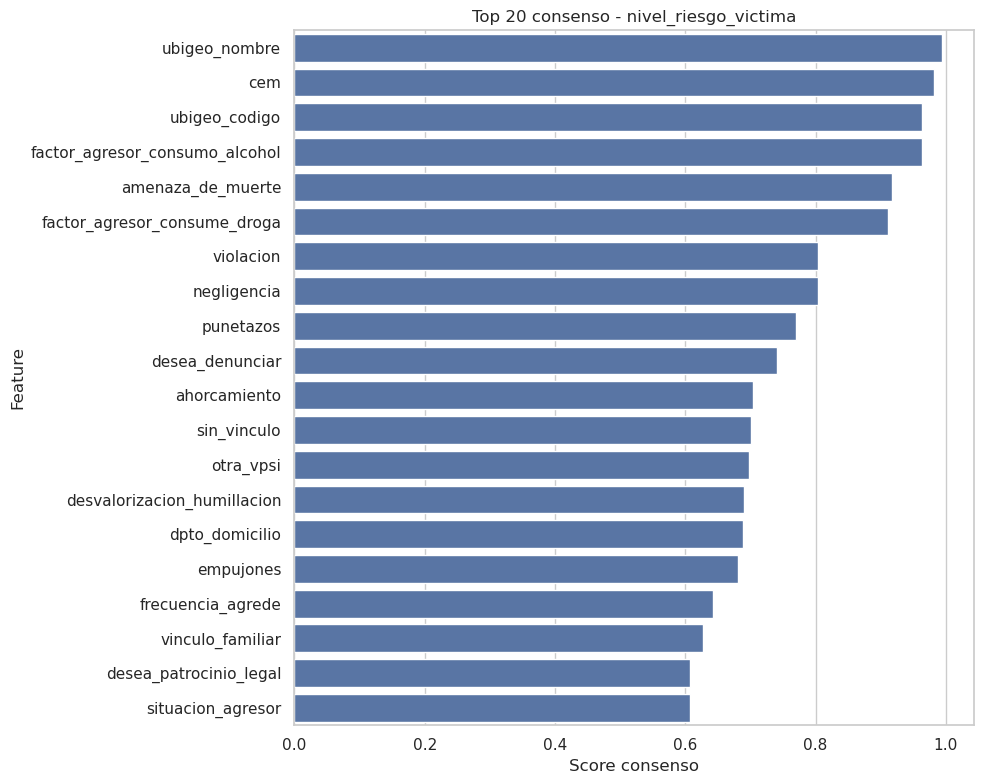

In [7]:
results["nivel_riesgo_victima"] = run_feature_selection_for_target(
    df_all=df,
    X_all=X_raw,
    target="nivel_riesgo_victima",
    sample_size=SAMPLE_SIZE,
    random_state=52,
)

top30_nr = results["nivel_riesgo_victima"]["consenso"].head(30).copy()
print("## Top 30 consenso para nivel_riesgo_victima")
print(top30_nr[["feature", "score_consenso", "score_cv", "score_mi", "score_rf", "score_perm", "score_rfe"]].to_markdown(index=False))
print(f"\nF1 macro RF baseline (muestra): {results['nivel_riesgo_victima']['rf_f1_macro_test']:.4f}")

plt.figure(figsize=(10, 8))
sns.barplot(data=top30_nr.head(20), x="score_consenso", y="feature", orient="h")
plt.title("Top 20 consenso - nivel_riesgo_victima")
plt.xlabel("Score consenso")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 8) Contexto MOES y aplicacion en esta tesis

**Que es MOES**
- MOES (*Multi-Objective Evolutionary Search*) es una estrategia evolutiva de seleccion de variables.
- En lugar de optimizar una sola metrica, optimiza simultaneamente dos objetivos: minimizar error predictivo y minimizar numero de variables.
- El resultado natural de MOES es un frente de Pareto: conjunto de soluciones no dominadas (no existe otra mejor en ambos objetivos al mismo tiempo).

**Por que lo aplicamos a nuestra data**
- Nuestra seleccion hibrida (Cramer's V + MI + RF + Permutation + RFECV) produce un ranking robusto, pero no optimiza explicitamente el tamano minimo del subconjunto.
- MOES nos permite contrastar: "que tan cerca del mejor desempeno podemos estar usando menos variables".
- Esta comparacion fortalece la metodologia de tesis al evaluar dos paradigmas: ranking por consenso vs busqueda evolutiva multiobjetivo.

**Nota tecnica**
- En este notebook implementamos una aproximacion practica de MOES-RF en sklearn para comparacion reproducible y costo computacional controlado.

## 9) MOES-RF para comparar con seleccion hibrida
Se ejecuta una busqueda evolutiva multiobjetivo (error y numero de variables) sobre un conjunto candidato de features y se compara contra el Top 30 de consenso.
En esta version se fuerza un minimo de variables (`min_features`) para evitar soluciones demasiado pequenas e inestables.

In [8]:
moes_results = {}
for t in targets:
    print(f"\n=== MOES-RF para {t} ===")
    moes_results[t] = run_moes_rf_for_target(
        df_all=df,
        X_all=X_raw,
        target=t,
        sample_size=SAMPLE_SIZE,
        random_state=42,
        n_generations=10,
        pop_size=40,
        min_features=8,
    )

    hybrid_top30 = set(results[t]["consenso"].head(30)["feature"].tolist())
    moes_set = set(moes_results[t]["moes_selected"]["feature"].tolist())
    inter = len(hybrid_top30.intersection(moes_set))
    union = len(hybrid_top30.union(moes_set)) if len(hybrid_top30.union(moes_set)) > 0 else 1
    jaccard = inter / union

    print(f"MOES F1 best: {moes_results[t]['moes_f1_best']:.4f}")
    print(f"MOES n_features best: {moes_results[t]['moes_n_features_best']}")
    print(f"Interseccion MOES vs Hybrid Top30: {inter}")
    print(f"Jaccard MOES vs Hybrid Top30: {jaccard:.4f}")

    display(moes_results[t]["moes_selected"].head(30))



=== MOES-RF para tipo_violencia ===
MOES F1 best: 0.9586
MOES n_features best: 22
Interseccion MOES vs Hybrid Top30: 21
Jaccard MOES vs Hybrid Top30: 0.6774


,feature,moes_rank
0,gritos_insultos,1
1,empujones,2
2,punetazos,3
3,violacion,4
4,vinculo_agresor_victima,5
5,otra_vpsi,6
6,otra_vfis,7
7,bofetadas,8
8,jalones_cabello,9
9,negligencia,10



=== MOES-RF para nivel_riesgo_victima ===
MOES F1 best: 0.5252
MOES n_features best: 16
Interseccion MOES vs Hybrid Top30: 12
Jaccard MOES vs Hybrid Top30: 0.3529


,feature,moes_rank
0,amenaza_de_muerte,1
1,violacion,2
2,ubigeo_nombre,3
3,ubigeo_codigo,4
4,factor_agresor_consume_droga,5
5,cem,6
6,otra_vpsi,7
7,vinculo_familiar,8
8,gritos_insultos,9
9,vinculo_agresor_victima,10


## 10) Exportables CSV
Se guardan rankings hibridos y resultados MOES para comparacion final.

In [9]:
OUT = "/home/munasqa/MAESTRIA/opencode"
for t in targets:
    results[t]["cv"].to_csv(f"{OUT}/ranking_cv_{t}.csv", index=False)
    results[t]["mi"].to_csv(f"{OUT}/ranking_mi_{t}.csv", index=False)
    results[t]["rf"].to_csv(f"{OUT}/ranking_rfimp_{t}.csv", index=False)
    results[t]["perm"].to_csv(f"{OUT}/ranking_perm_{t}.csv", index=False)
    results[t]["rfe"].to_csv(f"{OUT}/ranking_rfe_{t}.csv", index=False)
    results[t]["consenso"].head(30).to_csv(f"{OUT}/top30_consenso_{t}.csv", index=False)
    if 'moes_results' in globals() and t in moes_results:
        moes_results[t]["moes_selected"].to_csv(f"{OUT}/ranking_moes_{t}.csv", index=False)
        moes_results[t]["moes_pareto"].drop(columns=["mask"], errors="ignore").to_csv(f"{OUT}/pareto_moes_{t}.csv", index=False)

print("Exportables generados en:", OUT)


Exportables generados en: /home/munasqa/MAESTRIA/opencode
